# **Laboratorio N°5: Número de Condición**


In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Ejercicio 1

En este ejercicio vamos a probar o refutar algunas propiedades sobre el numero de condicion.
En cada item tendremos un propiedad que puede ser verdadera o falsa.
 - En caso de ser verdadera: dar su demostracion.
 - En caso de ser falsa: utilizar numpy para dar un contraejemplo.

Utilizar el comando `np.linalg.cond`.

In [2]:
A = np.array([[0.5, 0],
              [0, 0.5]])

B = np.array([[8,2],
              [3,5]])

**(a)** $Cond_2(A)$ + $Cond_2(B)$ = $Cond_2(A+B)$

In [3]:
np.linalg.cond(A,2)+np.linalg.cond(B,2)

3.618033988749896

In [4]:
np.linalg.cond(A+B,2)

2.4213657651833183

In [5]:
np.isclose(np.linalg.cond(A,2)+np.linalg.cond(B,2), np.linalg.cond(A+B,2) )

False

**(b)** $Cond_1(A)$ - $Cond_1(B)$ = $Cond_2(A-B)$

In [6]:
np.isclose(np.linalg.cond(A,1)-np.linalg.cond(B,1), np.linalg.cond(A-B,2) )

False

**(c)** $Cond_2(A)$ * $Cond_2(B)$ = $Cond_2(A.B)$

In [7]:
np.isclose(np.linalg.cond(A,2)*np.linalg.cond(B,2), np.linalg.cond(A*B,2) )

False

## Ejercicio 2

El objetivo de este ejercicio es estudiar el número de condición de
algunas matrices a medida que su tamaño aumenta.



**(a)** Programar funciones que, dado $n \in \mathbb{N}$, devuelvan las siguientes matrices de $\mathbb{R}^{n\times n}$. La función que define $B_n$ ya viene dada.


\begin{equation*}
A_n=
\begin{pmatrix}
\frac{1}{n} & 0 & 0 & \cdots  & n^2\\
0 & \frac{1}{n} & 0 & \cdots & 0 \\
0 & 0 & \frac{1}{n} & \cdots & 0\\
\vdots & \vdots & \vdots  & \ddots & \vdots\\
1 & 0 & 0 & \cdots &  \frac{1}{n}\\
\end{pmatrix}
\qquad
B_n=
\begin{pmatrix}
4 & 1 & 0 & \cdots & 0 & 0\\
1 & 4 & 1 & \cdots & 0 & 0 \\
0 & 1 & 4 & \ddots &  & \vdots\\
\vdots & \vdots & \ddots & \ddots & \ddots & \vdots \\
0 & 0 &  & \ddots & 4 & 1\\
0 & 0 & \cdots & \cdots & 1 & 4 \\
\end{pmatrix}
\qquad
H_n=
\begin{pmatrix}
1 & \frac{1}{2} & \frac{1}{3} & \cdots  & \frac{1}{n}\\
\frac{1}{2} & \frac{1}{3} & \frac{1}{4} & \cdots & \frac{1}{n+1} \\
\frac{1}{3} & \frac{1}{4} & \frac{1}{5} & \cdots & \frac{1}{n+2}\\
\vdots & \vdots & \vdots  & \ddots & \vdots\\
\frac{1}{n} & \frac{1}{n+1} & \frac{1}{n+2} & \cdots &  \frac{1}{2n-1}\\
\end{pmatrix}
\end{equation*}



**Sugerencia:** Utilizar la función `np.diag` que recibe un array de números y genera una matriz diagonal con elementos dados por el array.




In [8]:
def matriz_A(n):
    aux = np.zeros((n,n))
    aux[0,n-1] = n*n
    aux[n-1,0] = 1
    A = np.diag(np.full(n,1/n)) + aux
    return A

In [9]:
def matriz_B(n):
  B = np.eye(n, k=-1) + 4*np.eye(n, k=0) + np.eye(n, k=1)
  return B

In [10]:
def matriz_B_diag(n):
    B = np.diag(np.full(n,n)) + np.eye(n, k=1) + np.eye(n, k=-1)

In [11]:
def matriz_H(n):
    H = np.zeros((n,n))
    
    for i in range(0,n):
        H[i] = np.ones(n) / (np.arange(n)+i+1)

    return H

**(b)** Graficar para 100 vectores **unitarios** (en norma 2), $v\in\mathbb{R^2}$, $\; A_2v,\ B_2v,\ H_2v$

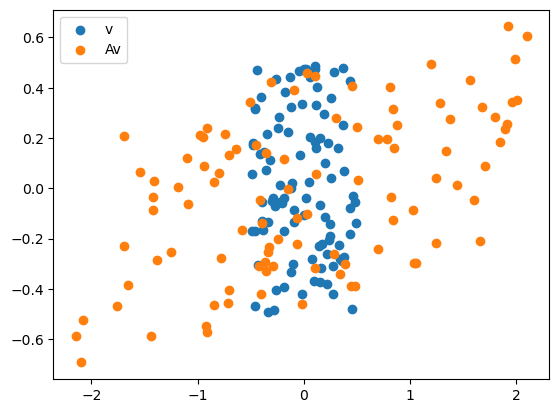

In [26]:
A = matriz_A(2)
V = np.random.rand(2, 100) - 0.5
AV = A@V

plt.scatter(V[0], V[1], label = "v")
plt.scatter(AV[0], AV[1], label = "Av")
plt.legend()


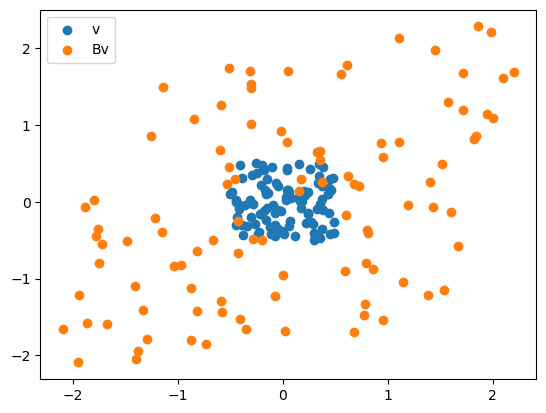

In [ ]:
B = matriz_B(2)
V = np.random.rand(2, 100) - 0.5

BV = B@V

plt.scatter(V[0], V[1], label = "v")
plt.scatter(BV[0], BV[1], label = "Bv")
plt.legend()


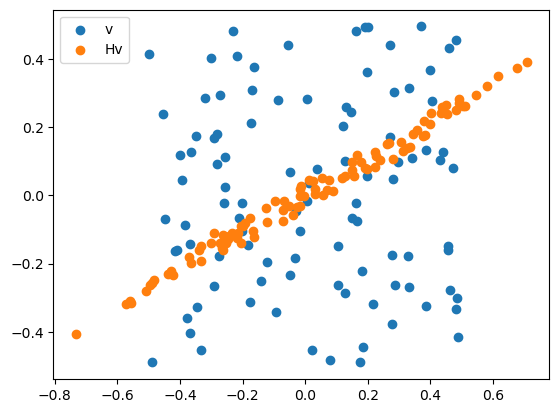

In [25]:
H = matriz_H(2)
V = np.random.rand(2, 100) - 0.5
HV = H@V

plt.scatter(V[0], V[1], label = "v")
plt.scatter(HV[0], HV[1], label = "Hv")
plt.legend()


**(c)** Programar una función que, dada una matriz $M_n$ y un número natural $N$, guarde en un vector el valor de $Cond_2(M_n)$ para $1\leq n \leq N$.

In [ ]:
def vector_condicion(M, N):
  #COMPLETAR
  #...
  return()

**(d)** Realizar gráficos del número de condición en norma 2 de las matrices definidas arriba para $N=10$.


In [ ]:
x= #COMPLETAR
y= #COMPLETAR

plt.plot(x, y)
plt.show()

**Sugerencia:** Si es necesario, utilizar una escala logarítmica en el eje $y$.

**(e)** Repetir el ítem (d) para la matriz de Hilbert con $N=50$. ¿Cómo se explica el comportamiento observado?

In [ ]:
#COMPLETAR

## Ejercicio 3 (Ej 20 - Práctica 2)

Sea
$A=\left(
\begin{array}{ccc}
3&0 & 0\\
0& \frac 54 & \frac 34\\
0& \frac 34 & \frac 54\\
\end{array}
\right).$



In [ ]:
A = np.array([[3.0, 0, 0], [0, 5/4, 3/4], [0, 3/4, 5/4]])

(a) Calcular $Cond_\infty(A)$.


In [29]:
np.linalg.cond(A,np.inf)

5.3999999999999995

(b) ¿Cuán chico debe ser el error relativo en los datos, $\frac{\|b-\tilde{b}\|}{\|b\|}$, si se desea que el error relativo en la aproximación de la solución, $\frac{\|x-\tilde{x}\|}{\|x\|}, $ sea menor que $10^{-4}$ (en $\|\cdot\|_{\infty}$)?



In [ ]:
#COMPLETAR

(c) Realizar experimentos numéricos para verificar las estimaciones del ítem anterior. Considerar $b=(3,2,2)^t$, que se corresponde con la solución exacta $x=(1,1,1)^t$. Generar vectores de error aleatorios, normalizarlos para que su norma sea tan chica como la estimada en el item anterior y perturbar $b$ obteniendo $\tilde{b}$. Finalmente, resolver $A\tilde{x}=\tilde{b}$ y verificar que $\|\tilde{x}-x\|<10^{-4}$.

In [ ]:
#COMPLETAR